In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

sys.path.append('../../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

## Load Norman 2019 data

Norman et al. 2019 (CRISPRa screen) — 105 single and 131 double perturbations in K562 cells.  
`slk_prepare_data` standardises the perturbation column to `obs['pert']` with NTC → `'NTC'`.

In [3]:
data = sc.read_h5ad("../../datasets/norman/Norman_2019.h5ad")
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]
print(f"Cells: {data.n_obs}   Genes: {data.n_vars}")
print(f"Single perts: {len(single_perts)}   Combo perts: {len(combo_perts)}   NTC cells: {(data.obs[p_key]==NTC).sum()}")

Cells: 111255   Genes: 19018
Single perts: 105   Combo perts: 131   NTC cells: 11835


## Gene filtering

Keep highly variable genes (seurat_v3, top 2000) **plus** any gene that appears as a perturbation target (single or split from combo). This reduces the feature space while ensuring every perturbed gene is retained.

In [4]:
# Collect all individual gene names that appear as perturbation targets
pert_genes = set()
for p in all_perts:
    if p != NTC:
        for g in str(p).split('+'):
            pert_genes.add(g.strip())

# HVG selection on raw counts (seurat_v3 expects counts in X)
sc.pp.highly_variable_genes(data, n_top_genes=2000, flavor='seurat_v3', subset=False)

# Union: HVG mask OR gene is a perturbation target
pert_mask = data.var_names.isin(pert_genes)
keep_mask = data.var['highly_variable'] | pert_mask
data = data[:, keep_mask].copy()

n_hvg      = data.var['highly_variable'].sum()
n_pert_only = (pert_mask[keep_mask] & ~data.var['highly_variable']).sum()
print(f"Kept {data.n_vars} genes  ({n_hvg} HVG + {n_pert_only} pert-only not in HVG)")
print(f"Pert genes in var_names: {pert_mask[keep_mask].sum()} / {len(pert_genes)}")

Kept 2040 genes  (2000 HVG + 40 pert-only not in HVG)
Pert genes in var_names: 102 / 105


## Compute treatment effects

Ground-truth per-perturbation mean effects (log2-CPM vs NTC), computed for all labels including combinations.

In [5]:
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
te = data.uns['treat_effect']
print(f"treat_effect: {te.n_obs} perturbations × {te.n_vars} genes")
print(f"  single: {sum('+' not in p and p != NTC for p in te.obs_names)}   combo: {sum('+' in p for p in te.obs_names)}")

100%|██████████| 236/236 [00:03<00:00, 64.22it/s]

treat_effect: 236 perturbations × 2040 genes
  single: 105   combo: 131


## Train VAE (combinatorial mode)

Architecture:
- **Encoder** — background `z0` via `z0_encoder` on NTC; perturbed `z` via shared `z_encoder`
- **Gate** `W[p]` (HardConcrete, shape P×d) — sparse binary mask over latent dims
- **Shift** `z = z0*(1 − W[p]) + A[p]*W[p]` — mechanism shift only in gated dims (linear mode)
- **Decoder** — perturbation-agnostic NB decoder
- **Combinatorial** — labels like `GENE1+GENE2` are split; component shifts are summed at training time
- **Counterfactuals** — abduct NTC `z0`, K-means centroids, apply union(W) gate + Σ A_j*W_j shift

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

results = slk.tl.run_single(
    data,
    model='vae',
    # batch_size=2048,
    ce_lambda=1e-1,
    l0_lambda=5.,
    # l1_lambda=10.,
    rank=6,
    shuffle=True,
    num_workers=0,
    device=device,
    # latent_dim=16,
    num_epochs=500,
    validate_every=50,
    patience=20,
    combinatorial=True,
    debug=True,
    use_synergy=True
    # n_epochs_kl_warmup=20
)
model = results['model']

Device: cuda
Training VAE on cuda …


Epochs: 100%|██████████| 2/2 [00:07<00:00,  3.70s/it, ATE=nan, CE=nan, ELBO=1527.2877, KLw=0.04, R2_ntc=nan, R2_p=nan, acc=nan, pi25=nan, pi99=nan, tau=0.305]


## Save & load

In [7]:
os.makedirs('../results', exist_ok=True)
slk.tl.save_results(results, '../results/norman_vae.pth')

In [8]:
model = slk.tl.load_results('../results/norman_vae.pth')
print(type(model))

<class 'sherlock.tools._models.VAE'>


## Evaluate

`z` — perturbed latent per cell.  
`rho_corr` — Pearson correlation of Cholesky-structured `A[p]` vectors.  
For z_corr, only single-perturbation cells are used.

In [9]:
slk.tl.eval_single(model, data, obsm_key='z', uns_key='results', device=device)
print(list(data.uns['results'].keys()))

['z_corr', 'z_perts', 'perts', 'rho_corr', 'rho_perts', 'rho_embed', 'acc', 'z_rho_corr', 'W', 'counterfactual_effect_size', 'condition_perturbation_interaction', 'conditions', 'synergy_matrix', 'synergy_params']


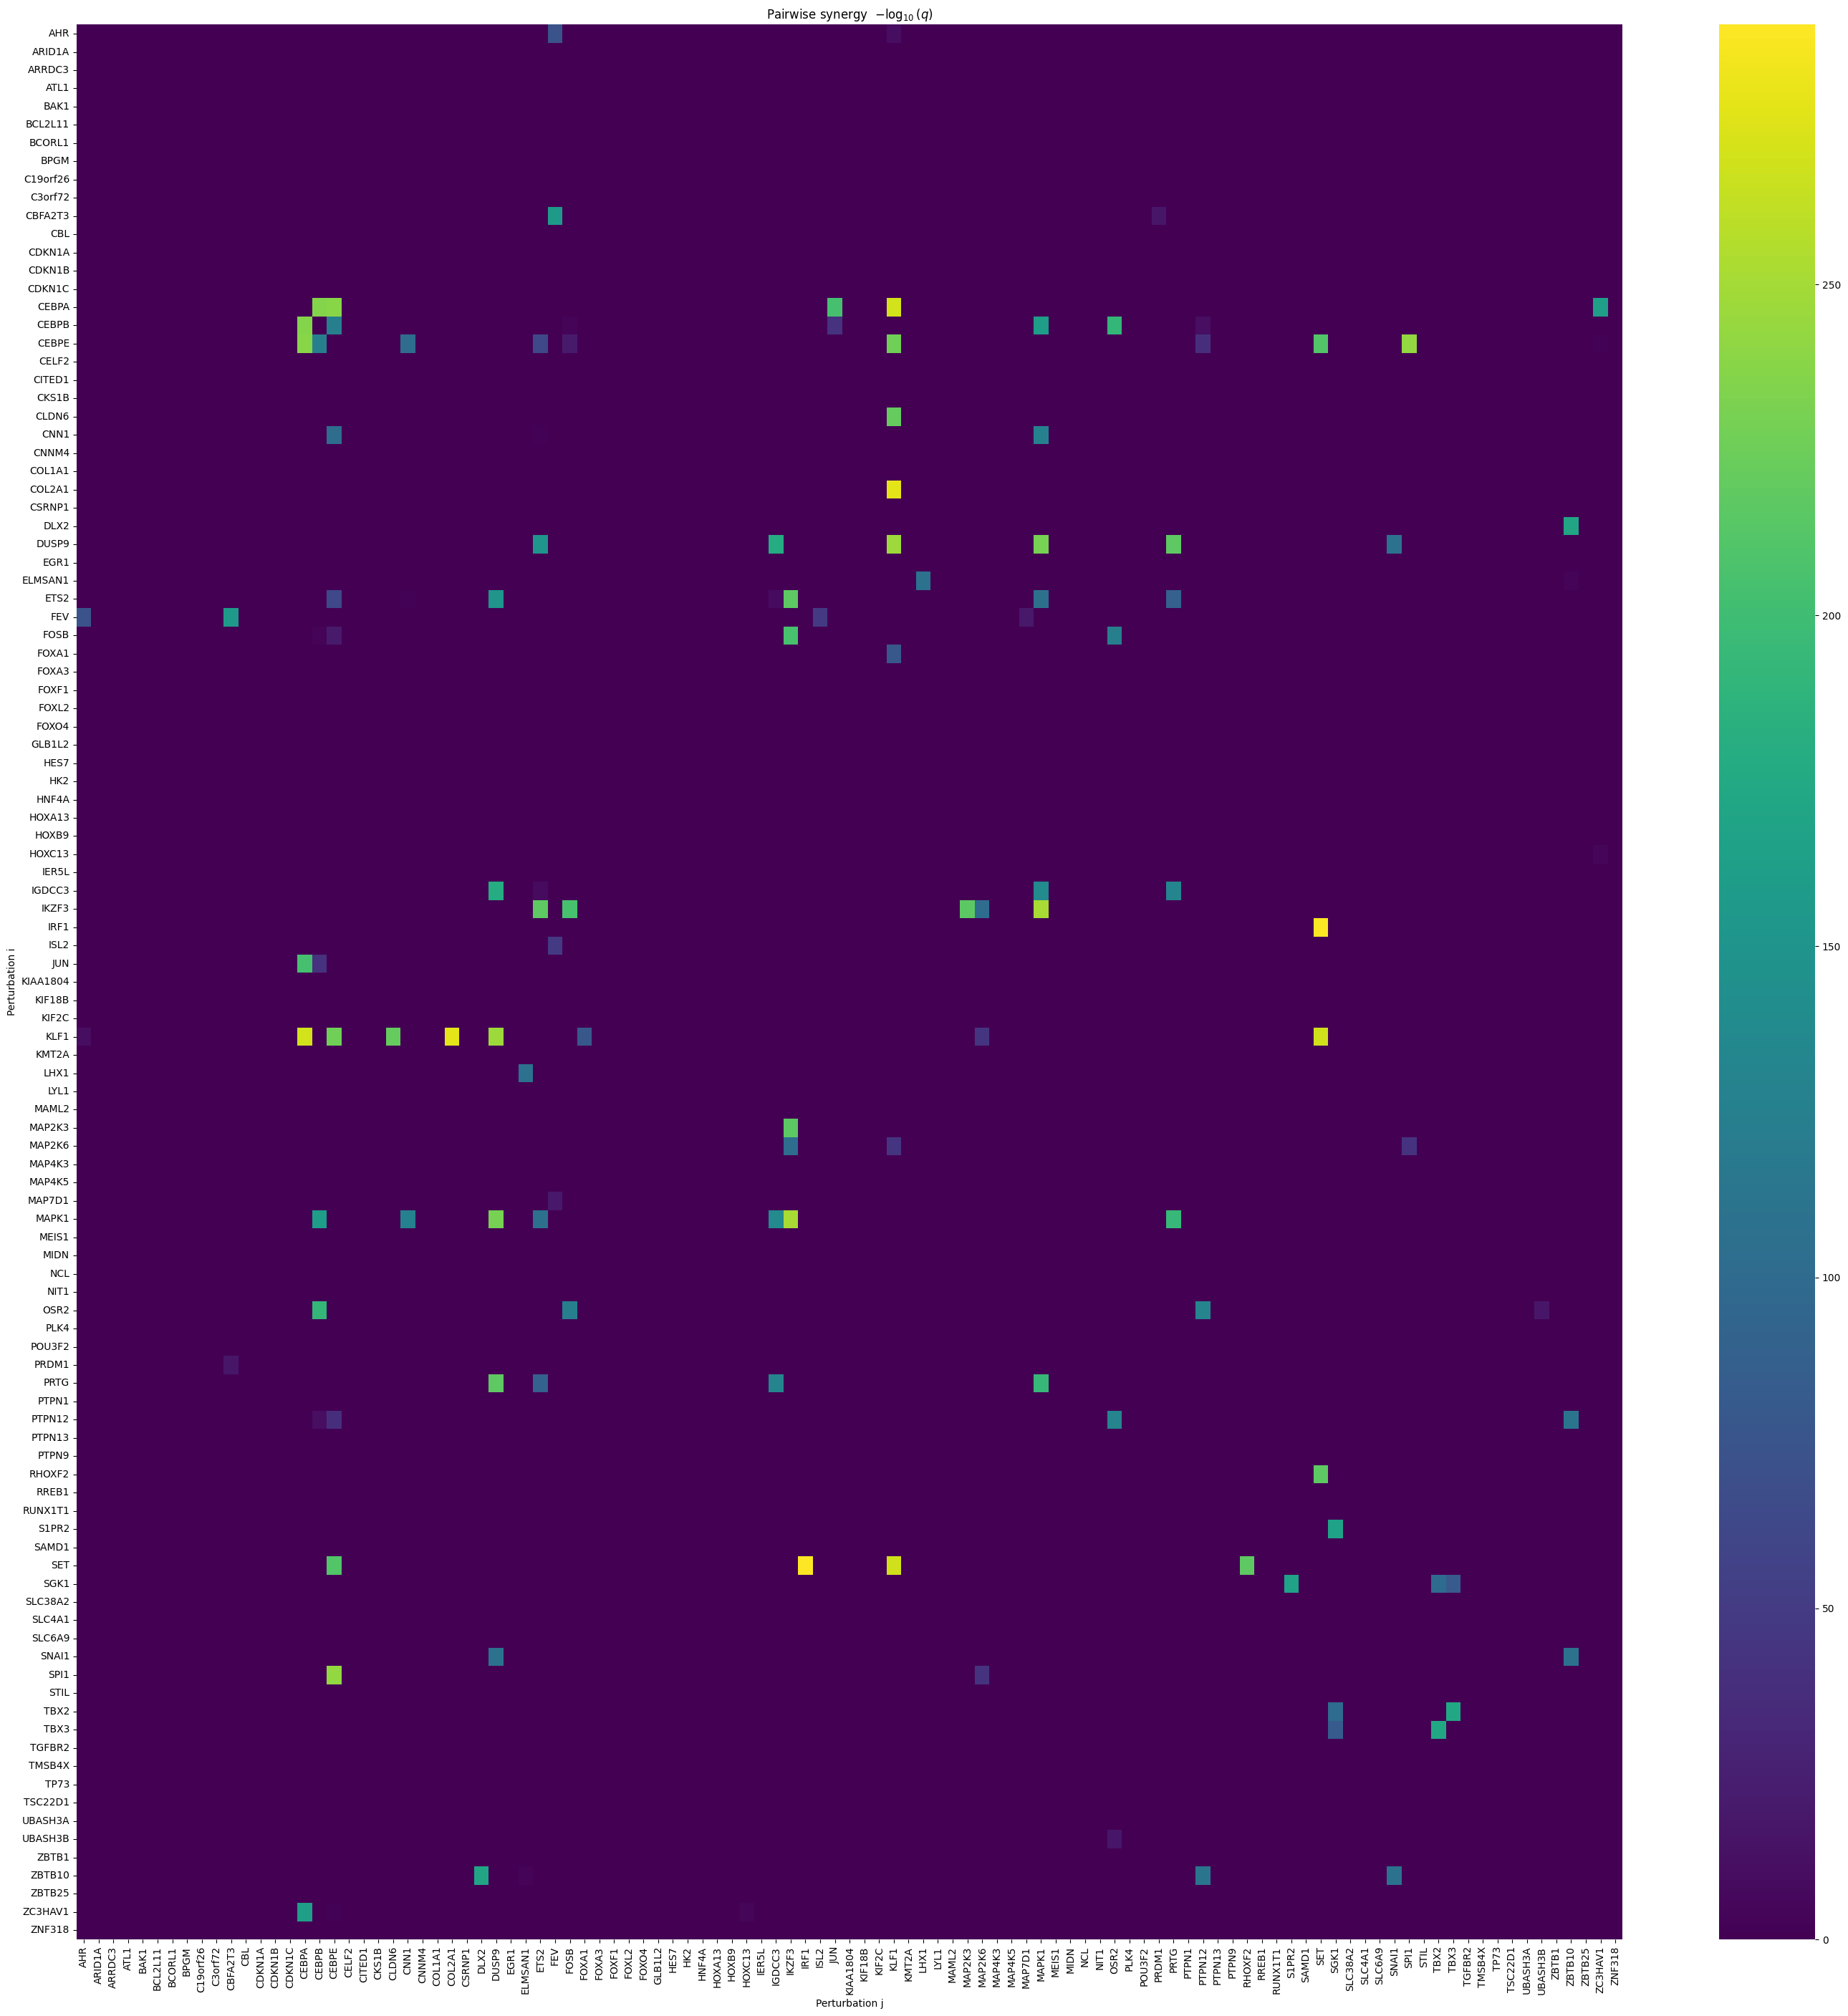

In [135]:
syn_df = slk.pl.plot_synergy(data)

<Axes: xlabel='effect_size', ylabel='Count'>

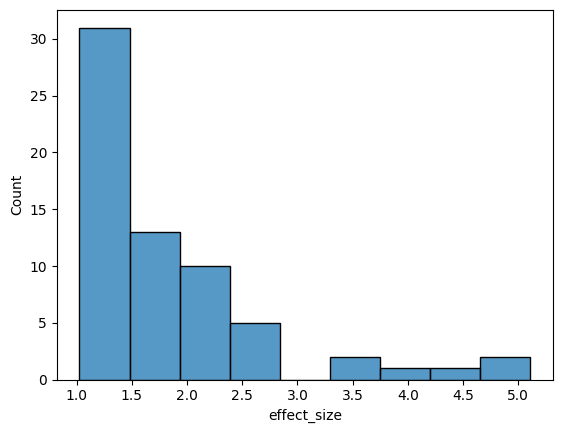

In [143]:
sns.histplot(syn_df[syn_df['qval']<0.05]['effect_size'])

In [149]:
syn_df = syn_df.sort_values('qval').reset_index(drop=True)
effect_size_threshold = 1
print("Out of {} tested pairs, {} are significant at q < 0.05".format(syn_df.shape[0], (syn_df[syn_df['effect_size'] > effect_size_threshold]['qval'] < 0.05).sum()))

Out of 131 tested pairs, 65 are significant at q < 0.05


/home/jm5707/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


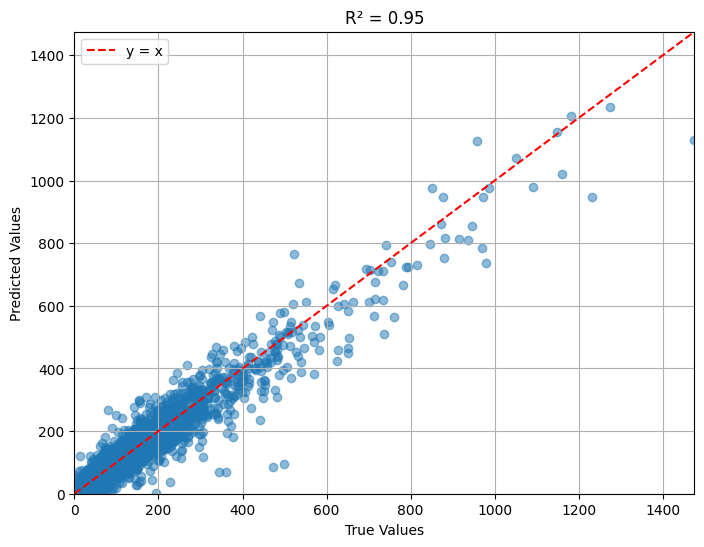

In [26]:
slk.pl.plot_r2(data)

## UMAP of perturbed latent z  (single perturbations only)

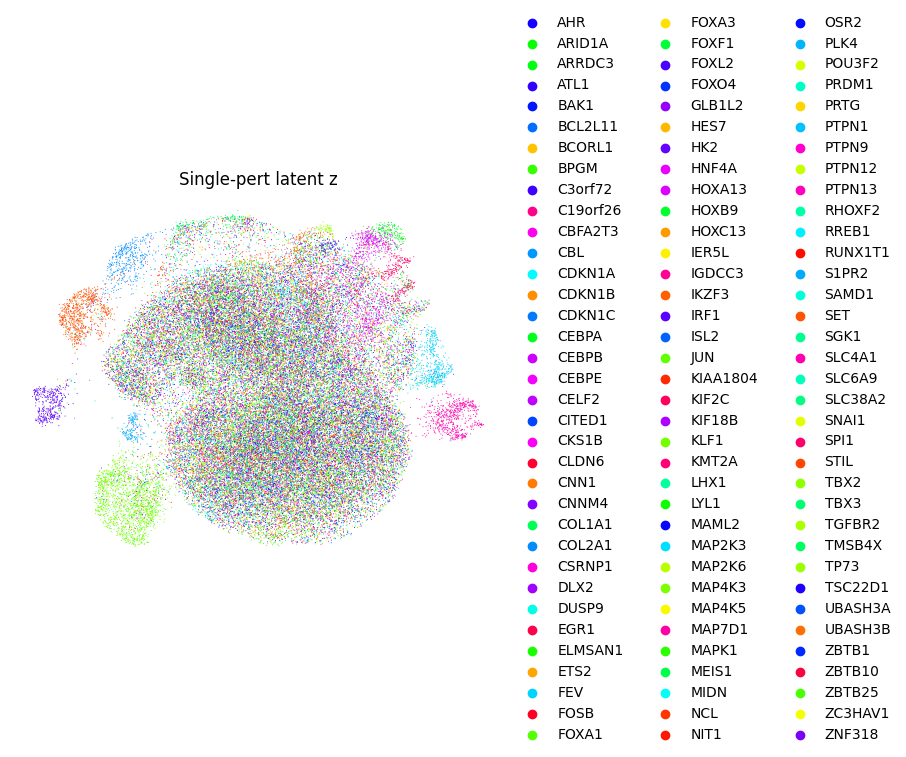

In [27]:
import random

single_mask = (
    (data.obs[p_key] != NTC) &
    (~data.obs['perturbation_name'].astype(str).str.contains(r'\+', regex=True))
)
sub = data[single_mask].copy()

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

n_cats  = sub.obs[p_key].nunique()
palette = sns.color_palette('hsv', n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color=p_key, palette=palette, frameon=False, title='Single-pert latent z')

## Perturbation embedding correlation (rho_corr)

/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


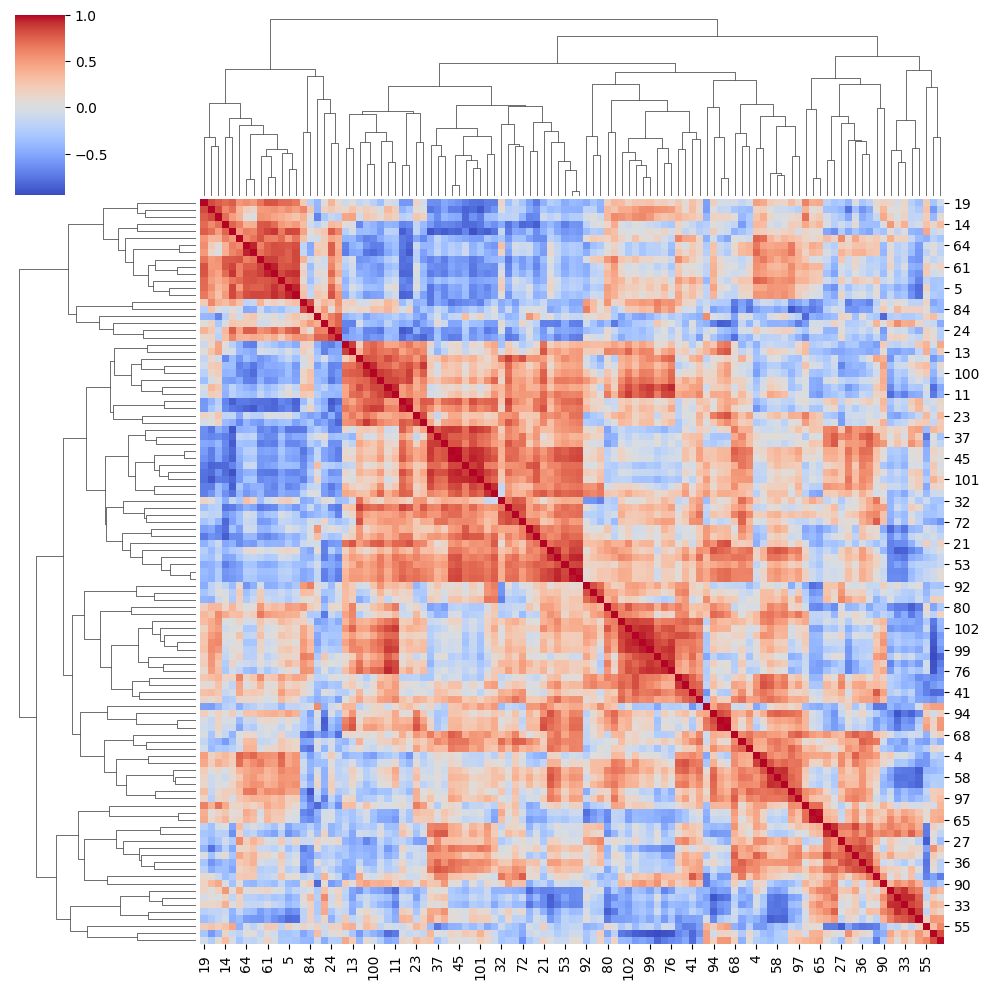

In [28]:
slk.pl.plot_corr(data)

## ATE — counterfactual effect prediction

**Protocol**
1. Encode NTC cells → background `z0_i`
2. K-means centroids `c_k` in background space (K=25)
3. For each perturbation `p`:  
   — single: `z_cf = c_k * (1 − W[p]) + A[p]*W[p]`  
   — combo `A+B`: `z_cf = c_k * (1 − max(W_A, W_B)) + A_A*W_A + A_B*W_B`
4. Decode → expected counts, log2-CPM normalise, subtract NTC baseline
5. Pearson r vs observed `treat_effect`

In [29]:
ate = model.predict_counterfactual_effects(
    data,
    n_centroids=25,
    observed_effect=data.uns['treat_effect'],
)
print(f"Pearson r (predicted vs observed ATE, all perts): {ate['corr']:.4f}")

Pearson r (predicted vs observed ATE, all perts): 0.6483


In [30]:
# Break down by single vs combo perturbations
from scipy.stats import pearsonr

pred_df = ate['predicted_df']
obs_df  = ate['observed_df']

single_idx = [p for p in pred_df.index if '+' not in str(p)]
combo_idx  = [p for p in pred_df.index if '+' in str(p)]

def _r(idx):
    if not idx:
        return float('nan')
    x = pred_df.loc[idx].values.ravel()
    y = obs_df.loc[idx].values.ravel()
    v = np.isfinite(x) & np.isfinite(y)
    return pearsonr(x[v], y[v])[0] if v.sum() > 2 else float('nan')

print(f"  Single perts ({len(single_idx):3d}): Pearson r = {_r(single_idx):.4f}")
print(f"  Combo  perts ({len(combo_idx):3d}): Pearson r = {_r(combo_idx):.4f}")

  Single perts (105): Pearson r = 0.5714
  Combo  perts (131): Pearson r = 0.6754


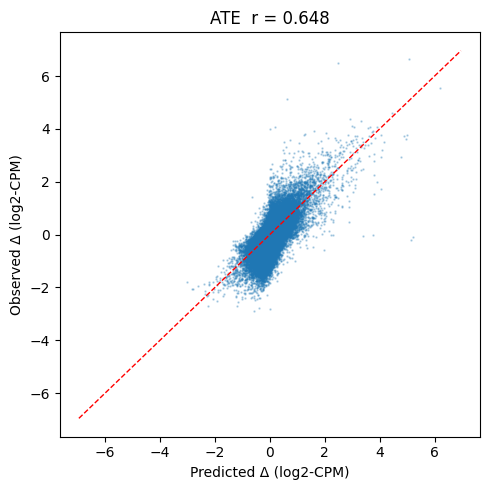

In [31]:
# Scatter: predicted vs observed ATE (all perts, flattened over genes)
x_flat = pred_df.values.ravel()
y_flat = obs_df.values.ravel()
valid  = np.isfinite(x_flat) & np.isfinite(y_flat)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x_flat[valid], y_flat[valid], s=0.5, alpha=0.3, rasterized=True)
lim = max(abs(x_flat[valid]).max(), abs(y_flat[valid]).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
ax.set_xlabel('Predicted Δ (log2-CPM)')
ax.set_ylabel('Observed Δ (log2-CPM)')
ax.set_title(f'ATE  r = {ate["corr"]:.3f}')
plt.tight_layout()
plt.show()

## z_corr vs rho_corr consistency

In [32]:
from scipy.stats import pearsonr, spearmanr

z_corr   = data.uns['results']['z_corr']
rho_corr = data.uns['results']['rho_corr']

pearson  = pearsonr(z_corr.flatten(),  rho_corr.flatten())
spearman = spearmanr(z_corr.flatten(), rho_corr.flatten())
print(f"Spearman ρ = {spearman.statistic:.3f}  (p = {spearman.pvalue:.1e})")
print(f" Pearson  r = {pearson.statistic:.3f}  (p = {pearson.pvalue:.1e})")

Spearman ρ = 0.675  (p = 0.0e+00)
 Pearson  r = 0.689  (p = 0.0e+00)


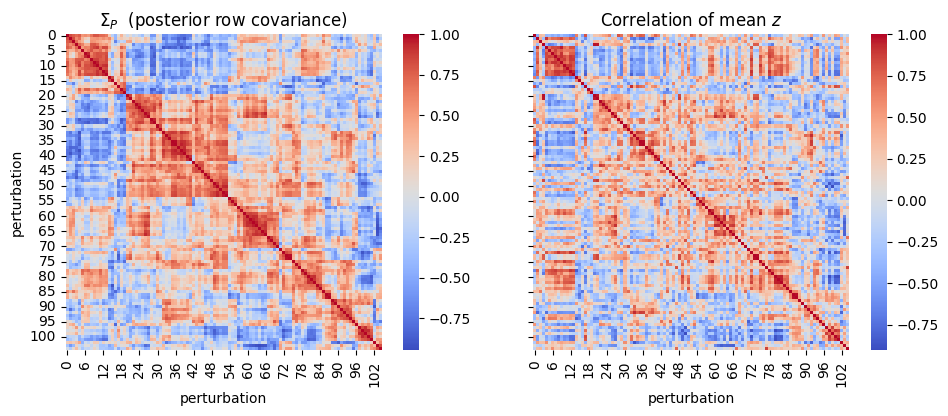

In [33]:
slk.pl.plot_zcorr(data)

## Gate W analysis

`W[p]` is a HardConcrete gate of shape `(P, d)`. Near-binary values indicate the model has learned sparse, perturbation-specific latent dimensions.

W shape: (105, 16)


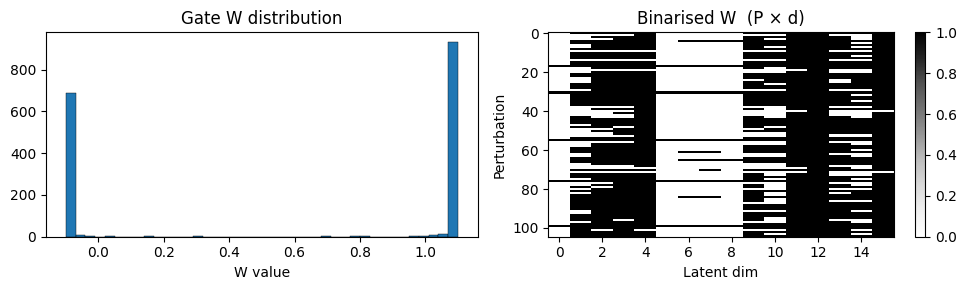

Avg active dims per pert: 9.2 / 16


In [34]:
W = data.uns['results']['W']   # (P, latent_dim)
print(f"W shape: {W.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(W.flatten(), bins=40, edgecolor='k', linewidth=0.3)
axes[0].set_title('Gate W distribution')
axes[0].set_xlabel('W value')

W_bin = (W > 0.5).astype(float)
im = axes[1].imshow(W_bin, aspect='auto', cmap='Greys', interpolation='nearest')
axes[1].set_title('Binarised W  (P × d)')
axes[1].set_xlabel('Latent dim')
axes[1].set_ylabel('Perturbation')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

print(f"Avg active dims per pert: {W_bin.sum(1).mean():.1f} / {W.shape[1]}")

## Perturbation clustering

Cluster `rho_corr` (correlation of learned `A[p]` vectors) and visualise groups on the single-pert UMAP.

In [43]:
rho_perts = data.uns['results']['rho_perts']
C = rho_corr
print(f"rho_corr: {C.shape}  |  perts: {len(rho_perts)}")

rho_corr: (105, 105)  |  perts: 105


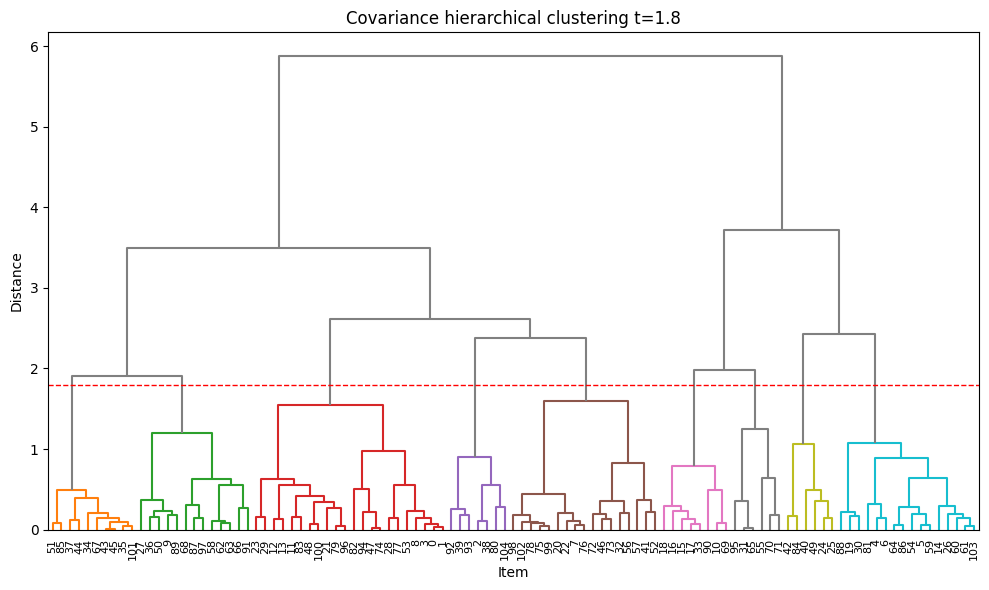

,group
AHR,3
ARID1A,3
ARRDC3,4
ATL1,3
BAK1,9
...,...
ZBTB1,3
ZBTB10,1
ZBTB25,5
ZC3HAV1,9


In [49]:
groups       = slk.tl.cluster_rho(data, t=1.8, rho_corr=C, show=True)
named_groups = slk.tl.group2name(groups, list(rho_perts))
named_groups

pert_group
1     4557
2     6828
3    11248
4     3530
5     8490
6     4741
7     5575
8     2698
9    10068
Name: count, dtype: int64


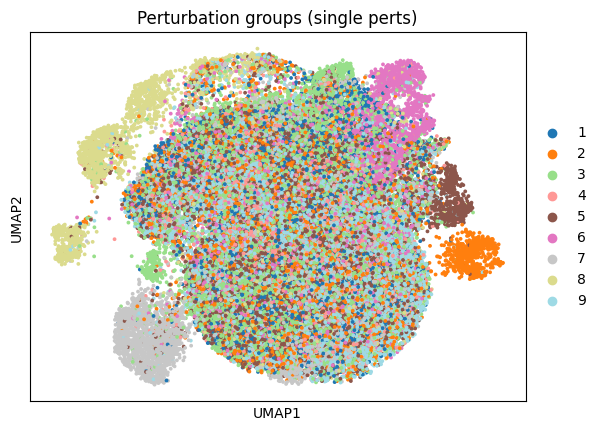

In [50]:
# Colour single-pert UMAP by learned perturbation group
gene_to_group = named_groups['group'].to_dict()
sub.obs['pert_group'] = sub.obs[p_key].map(gene_to_group).fillna(-1).astype('category')

print(sub.obs['pert_group'].value_counts().sort_index())
sc.pl.umap(sub, color=['pert_group'], title='Perturbation groups (single perts)', palette='tab20', size=30)

## Synergy scoring

In [138]:
erythroid = [
    # Globins
    "HBA1", "HBA2", "HBB", "HBG1", "HBG2", "HBE1", "HBZ", "HBD",
    # Membrane/structural
    "GYPA", "GYPB", "GYPC", "SLC4A1", "EPB42", "EPB41",
    "ANK1", "SPTA1", "SPTB", "RHAG",
    # Heme synthesis
    "ALAS2", "ALAD", "HMBS", "UROS", "UROD", "CPOX", "PPOX", "FECH", "TMEM14C",
    # Iron/chaperone
    "AHSP", "TFRC", "SLC25A37", "STEAP3", "FTH1", "FTL",
    # Transcription factors
    "KLF1", "GATA1", "TAL1", "ZFPM1", "NFE2", "LMO2", "MYB",
    # Signaling
    "EPOR", "STAT5A",
    # Metabolism
    "CA1", "CA2", "PKLR", "BPGM", "KCNN4",
    # Maturation
    "BNIP3L",
]

myeloid = [
    "SPI1", "CEBPA", "CEBPB", "CEBPE",
    "MPO", "ELANE", "LYZ", "S100A8", "S100A9", "CSF3R"
]

ifn_stress = [
    "IRF1", "STAT1", "ISG15", "IFIT1", "IFIT2", "IFIT3",
    "MX1", "OAS1", "DDIT3", "HSPA1A"
]

proliferation = [
    "MKI67", "TOP2A", "PCNA", "MCM2", "MCM3", "MCM4",
    "MCM5", "MCM6", "MCM7"
]

gene_sets = {
    "erythroid": erythroid,
    "myeloid": myeloid,
    "ifn_stress": ifn_stress,
    "proliferation": proliferation,
}

for name, genes in gene_sets.items():
    genes = [g for g in genes if g in data.var_names]
    sc.tl.score_genes(data, genes, score_name=f"{name}_score")

In [150]:
from collections import Counter
from sklearn.cluster import KMeans
from scipy.stats import ttest_1samp

# ----- perturbation centroid UMAP -----
z          = data.obsm['z']
pert_vals  = data.obs[p_key].values
pert_obs   = data.obs[p_key].astype(str)
pert_names = [p for p in data.obs[p_key].unique() if p != NTC]
mean_z     = np.stack([z[pert_vals == p].mean(0) for p in pert_names])

pert_ad           = sc.AnnData(mean_z)
pert_ad.obs_names = pert_names
pert_ad.obs['erythroid_score'] = [
    data.obs.loc[pert_obs == p, 'erythroid_score'].mean() for p in pert_names
]

sc.pp.neighbors(pert_ad, n_neighbors=10, use_rep='X')
sc.tl.umap(pert_ad, min_dist=0.4)
coords  = pd.DataFrame(pert_ad.obsm['X_umap'], index=pert_ad.obs_names, columns=['x', 'y'])
ctrl_m  = data.obs.loc[pert_obs == NTC, 'erythroid_score'].mean()

def _resolve_pair(g1, g2, idx):
    for cand in [f"{g1}+{g2}", f"{g2}+{g1}"]:
        if cand in idx:
            return cand
    return None

def _zscore(x):
    return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-10)

single_threshold = np.median([
    pert_ad.obs.loc[p, 'erythroid_score'] for p in pert_names if '+' not in p
])

# ----- residuals + shift detection for ALL tested pairs -----
rows = []
for _, srow in syn_df.iterrows():
    g1, g2     = srow['pert_i'], srow['pert_j']
    pair_label = _resolve_pair(g1, g2, set(pert_obs.values))
    if pair_label is None:
        continue
    g1_m   = data.obs.loc[pert_obs == g1,         'erythroid_score'].mean()
    g2_m   = data.obs.loc[pert_obs == g2,         'erythroid_score'].mean()
    pair_m = data.obs.loc[pert_obs == pair_label, 'erythroid_score'].mean()
    additive = g1_m + g2_m - ctrl_m

    # within-pair: does the combo land outside the range of both singles?
    if pair_m < min(g1_m, g2_m):   # combo lower than either single
        shift_type   = 'high→low'
        shift_effect = min(g1_m, g2_m) - pair_m
    elif pair_m > max(g1_m, g2_m):  # combo higher than either single
        shift_type   = 'low→high'
        shift_effect = pair_m - max(g1_m, g2_m)
    else:
        shift_type, shift_effect = 'mixed', 0.0

    combo_scores = data.obs.loc[pert_obs == pair_label, 'erythroid_score'].values
    _, shift_pval = ttest_1samp(combo_scores, additive)

    rows.append({'pair': f"{g1}+{g2}", 'pair_label': pair_label,
                 'g1': g1, 'g2': g2,
                 'g1_m': g1_m, 'g2_m': g2_m, 'pair_m': pair_m,
                 'residual':     pair_m - additive,
                 'effect_size':  srow['effect_size'],
                 'qval':         srow['qval'],
                 'shift_type':   shift_type,
                 'shift_effect': shift_effect,
                 'shift_pval':   shift_pval})

all_syn           = pd.DataFrame(rows)
all_syn['res_z']  = _zscore(all_syn['residual'].values)
all_syn['eff_z']  = _zscore(all_syn['effect_size'].values)
erythroid_syn     = all_syn[(all_syn['qval'] < 0.05) & (all_syn['effect_size'] >= effect_size_threshold)].sort_values('qval').reset_index(drop=True)

# ----- diagnostics -----
n_sig      = len(erythroid_syn)
n_directed = (erythroid_syn['shift_type'] != 'mixed').sum()
n_ttest    = ((erythroid_syn['shift_type'] != 'mixed') & (erythroid_syn['shift_pval'] < 0.05)).sum()
print(f"Model-significant pairs (q<0.05):        {n_sig}")
print(f"  with directional score shift:           {n_directed}")
print(f"  also t-test significant (p<0.05):       {n_ttest}")
print(f"  threshold (median single ery score):    {single_threshold:.4f}")

# use t-test only as a soft filter — show top pairs by shift_effect regardless
shift_sig = erythroid_syn[
    (erythroid_syn['shift_type'] != 'mixed') &
    (erythroid_syn['shift_pval'] < 0.05)
].sort_values('shift_effect', ascending=False)

print(f"\nTop directional shifts (no t-test filter):")
print(shift_sig[['pair', 'shift_type', 'shift_effect', 'shift_pval',
                  'g1_m', 'g2_m', 'pair_m']].head(15).to_string())


Model-significant pairs (q<0.05):        65
  with directional score shift:           31
  also t-test significant (p<0.05):       14
  threshold (median single ery score):    4.8507

Top directional shifts (no t-test filter):
            pair shift_type  shift_effect    shift_pval       g1_m       g2_m     pair_m
15  IKZF3+MAP2K3   low→high      5.728040  1.707595e-04  18.480717   6.387412  24.208757
5     DUSP9+KLF1   low→high      5.560833  3.524591e-12   7.199871   8.999896  14.560729
54    FEV+MAP7D1   low→high      1.545668  1.676621e-05   6.966524   4.538628   8.512192
42     SGK1+TBX2   low→high      1.412988  6.705207e-03   5.794182   5.508908   7.207170
44     SGK1+TBX3   low→high      1.166072  2.574473e-03   5.794182   5.223149   6.960254
62    CEBPB+FOSB   high→low      0.961179  5.699682e-04   4.642599   4.664345   3.681420
22     TBX2+TBX3   low→high      0.821968  3.474296e-02   5.508908   5.223149   6.330876
6     CEBPE+SPI1   high→low      0.696414  3.410363e-23   3.7

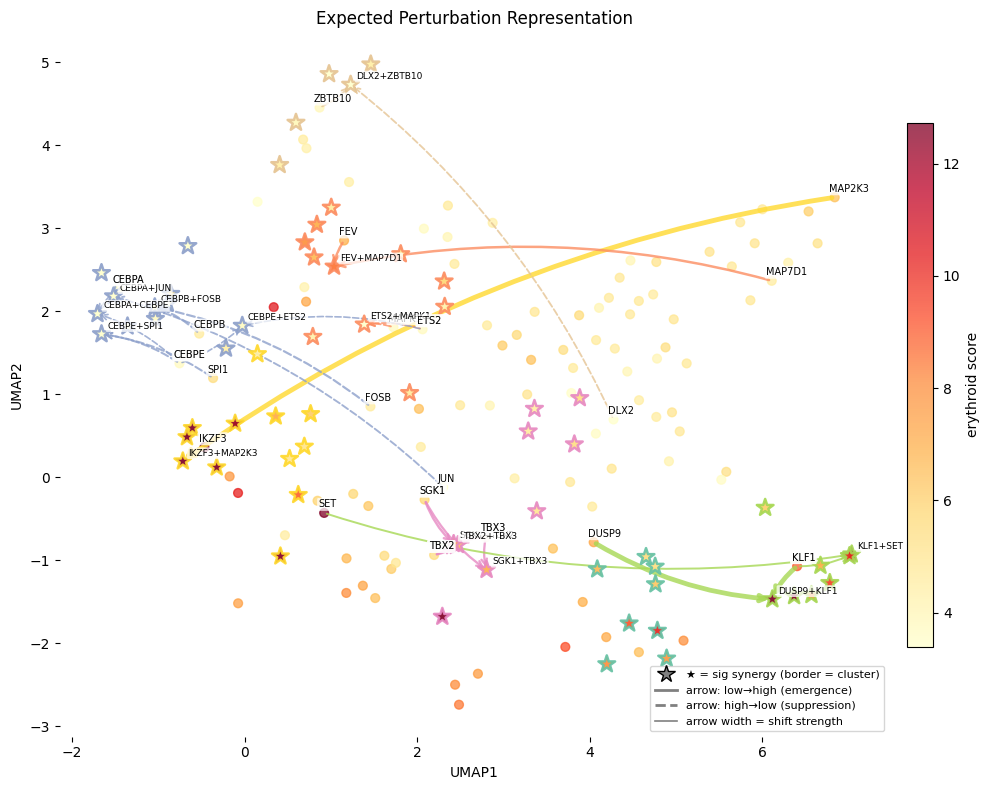

In [151]:
N_CLUSTERS   = 7
shift_colors = {'low→high': 'steelblue', 'high→low': 'tomato'}

sig_keys     = [_resolve_pair(r.g1, r.g2, coords.index) for _, r in erythroid_syn.iterrows()]
sig_keys     = [k for k in sig_keys if k is not None]
key_to_genes = {_resolve_pair(r.g1, r.g2, coords.index): (r.g1, r.g2)
                for _, r in erythroid_syn.iterrows()
                if _resolve_pair(r.g1, r.g2, coords.index) is not None}
shift_key_set = set(
    _resolve_pair(r.g1, r.g2, coords.index)
    for _, r in shift_sig.iterrows()
    if _resolve_pair(r.g1, r.g2, coords.index) is not None
)

single_names = [p for p in coords.index if '+' not in p]
single_ery   = pert_ad.obs.loc[single_names, 'erythroid_score'].values
combo_ery    = pert_ad.obs.loc[sig_keys, 'erythroid_score'].values
vlo, vhi     = np.percentile(np.concatenate([single_ery, combo_ery]), [5, 95])

# cluster all sig combos in UMAP space
sig_xy  = coords.loc[sig_keys, ['x', 'y']].values
km      = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10).fit(sig_xy)
cl_lbls = km.labels_
cl_pal  = sns.color_palette('Set2', N_CLUSTERS)

fig, ax = plt.subplots(figsize=(10, 8))

# singles: continuous erythroid score
sc_plt = ax.scatter(
    coords.loc[single_names, 'x'], coords.loc[single_names, 'y'],
    c=single_ery, cmap='YlOrRd', s=40, alpha=0.75, vmin=vlo, vmax=vhi, zorder=2)
plt.colorbar(sc_plt, ax=ax, label='erythroid score', fraction=0.03, pad=0.02, shrink=0.8)

# all sig combos: erythroid score + cluster-colored border
for cl in range(N_CLUSTERS):
    cl_keys = [k for k, l in zip(sig_keys, cl_lbls) if l == cl]
    ax.scatter(
        coords.loc[cl_keys, 'x'], coords.loc[cl_keys, 'y'],
        c=pert_ad.obs.loc[cl_keys, 'erythroid_score'].values,
        cmap='YlOrRd', vmin=vlo, vmax=vhi,
        s=160, marker='*', alpha=0.92, zorder=4,
        edgecolors=[cl_pal[cl]], linewidths=1.8)

# map every sig combo to its cluster color
key_to_cl_color = {k: cl_pal[l] for k, l in zip(sig_keys, cl_lbls)}

# arrows + labels only for shift_sig pairs
shift_row_map = {_resolve_pair(r.g1, r.g2, coords.index): r
                 for _, r in shift_sig.iterrows()
                 if _resolve_pair(r.g1, r.g2, coords.index) is not None}

eff_vals = shift_sig['shift_effect'].values
eff_min, eff_max = eff_vals.min(), eff_vals.max()

for pair_key, row in shift_row_map.items():
    color     = key_to_cl_color.get(pair_key, 'gray')
    linestyle = 'solid' if row['shift_type'] == 'low→high' else 'dashed'
    lw        = 1.2 + 2.3 * (row['shift_effect'] - eff_min) / (eff_max - eff_min + 1e-10)
    c_xy      = coords.loc[pair_key]
    for src_gene in [row['g1'], row['g2']]:
        if src_gene not in coords.index:
            continue
        s_xy = coords.loc[src_gene]
        ax.annotate('', xy=(c_xy['x'], c_xy['y']), xytext=(s_xy['x'], s_xy['y']),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                   linestyle=linestyle,
                                   connectionstyle='arc3,rad=0.12', alpha=0.8))
        ax.annotate(src_gene, (s_xy['x'], s_xy['y']),
                    fontsize=7, color='black', zorder=6,
                    xytext=(-4, 4), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.75, ec='none'))
    ax.annotate(f"{row['g1']}+{row['g2']}", (c_xy['x'], c_xy['y']),
                fontsize=6.5, color='black', zorder=6,
                xytext=(4, 4), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.75, ec='none'))

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gray',
           markeredgecolor='k', markersize=13, label='★ = sig synergy (border = cluster)'),
    Line2D([0], [0], color='gray', lw=2, linestyle='solid',  label='arrow: low→high (emergence)'),
    Line2D([0], [0], color='gray', lw=2, linestyle='dashed', label='arrow: high→low (suppression)'),
    Line2D([0], [0], color='gray', lw=1.2, linestyle='solid', label='arrow width = shift strength'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8, frameon=True)
ax.set_title('Expected Perturbation Representation')
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
ax.set_frame_on(False)
plt.tight_layout()
plt.show()


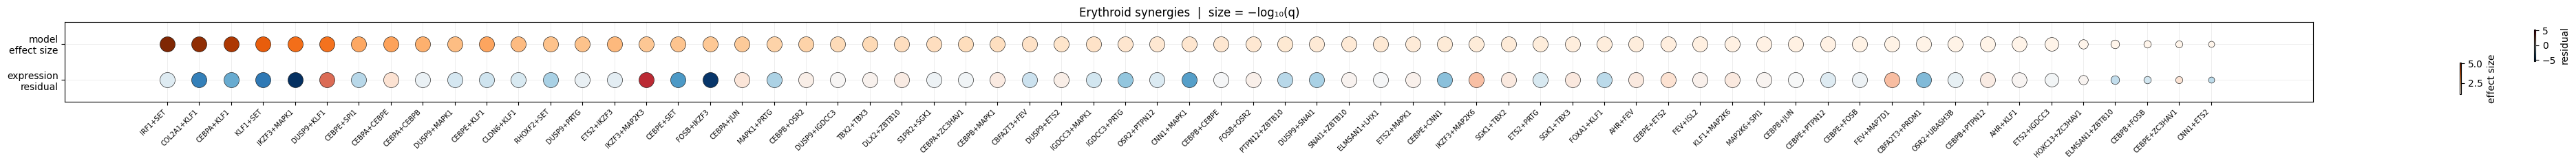

In [152]:
pair_order = erythroid_syn['pair'].tolist()  # sorted by qval
res_vals   = erythroid_syn['residual'].values.astype(float)
eff_vals   = erythroid_syn['effect_size'].values.astype(float)
q_vals     = erythroid_syn['qval'].values.astype(float)
sizes      = np.clip(-np.log10(q_vals + 1e-10) * 25, 15, 350).astype(float)

# row 0: signed residual → RdBu (diverging, centered at 0)
vmax      = np.nanmax(np.abs(res_vals))
norm_res  = plt.Normalize(-vmax, vmax)
cmap_res  = plt.cm.RdBu_r

# row 1: effect size → sequential (always positive, no meaningful zero-crossing)
norm_eff  = plt.Normalize(eff_vals.min(), eff_vals.max())
cmap_eff  = plt.cm.Oranges

fig, ax = plt.subplots(figsize=(max(7, len(pair_order) * 0.55 + 2), 2.5))

for j, (res, eff, sz) in enumerate(zip(res_vals, eff_vals, sizes)):
    ax.scatter(j, 0, s=sz, c=[cmap_res(norm_res(res))],
               edgecolors='k', linewidths=0.4, zorder=3)
    ax.scatter(j, 1, s=sz, c=[cmap_eff(norm_eff(eff))],
               edgecolors='k', linewidths=0.4, zorder=3)

ax.set_xticks(range(len(pair_order)))
ax.set_xticklabels(pair_order, rotation=45, ha='right', fontsize=7)
ax.set_yticks([0, 1])
ax.set_yticklabels(['expression\nresidual', 'model\neffect size'])
ax.set_ylim(-0.6, 1.6)
ax.set_title('Erythroid synergies  |  size = −log₁₀(q)')
ax.grid(True, alpha=0.3, lw=0.5)

fig.colorbar(plt.cm.ScalarMappable(cmap=cmap_res, norm=norm_res),
             ax=ax, label='residual', fraction=0.02, pad=0.01, shrink=0.4,
             anchor=(0, 0.85))
fig.colorbar(plt.cm.ScalarMappable(cmap=cmap_eff, norm=norm_eff),
             ax=ax, label='effect size', fraction=0.02, pad=0.06, shrink=0.4,
             anchor=(0, 0.15))
plt.tight_layout()
plt.show()
